In [1]:
from collections import deque

class EcoVueloGraph:

    def __init__(self):
        self.adj = {}

    # Para añadir ciudad
    def agregar_ciudad(self, ciudad):
        if ciudad in self.adj:
            print(f"La ciudad '{ciudad}' ya esta en el sistema.")
            return False
        self.adj[ciudad] = {}
        print(f"Ciudad '{ciudad}' añadida al sistema.")
        return True

  
    # Para eliminar la ciudad
    def eliminar_ciudad(self, ciudad):
        if ciudad not in self.adj:
            print(f" La ciudad '{ciudad}' no esta en el sistema.")
            return False

        # Eliminar la ciudad y todas sus rutas 
        del self.adj[ciudad]

        # Eliminar todas las rutas entrantes desde otras ciudades 
        for origen in self.adj:
            if ciudad in self.adj[origen]:
                del self.adj[origen][ciudad]

        print(f" Ciudad '{ciudad}' eliminada junto con sus rutas.")
        return True

  
    # Añadir ruta entre dos ciudades

    def agregar_ruta(self, origen, destino, peso): 
        if origen not in self.adj or destino not in self.adj:
            print(" Ambas ciudades deben existir en el sistema antes de crear una ruta.")
            return False
        if peso <= 0:
            print(" El peso debe ser un valor positivo.")
            return False

        self.adj[origen][destino] = peso
        print(f"Ruta creada: {origen} → {destino} ({peso} km).")
        return True

   
    # Eliminar ruta entre dos ciudades

    def eliminar_ruta(self, origen, destino):
        if origen in self.adj and destino in self.adj[origen]:
            del self.adj[origen][destino]
            print(f" Ruta {origen} → {destino} cancelada.")
            return True
        print(f" No existe una ruta directa {origen} → {destino}.")
        return False

   
    # buscar ruta entre dos ciudades 
   
    def buscar_ruta(self, origen, destino):
        exists = origen in self.adj and destino in self.adj[origen]
        if exists:
            print(f"Existe vuelo directo {origen} → {destino} "
                  f"({self.adj[origen][destino]} km).")
        else:
            print(f"No existe vuelo directo  {origen} → {destino}.")
        return exists


    # Buscar ciudad en el sistema
    def buscar_ciudad(self, ciudad):
        exists = ciudad in self.adj
        if exists:
            print(f" La ciudad '{ciudad}' está registrada en el sistema.")
        else:
            print(f" La ciudad '{ciudad}' NO está registrada en el sistema.")
        return exists

 
    # Buscar destino directo desde una ciudad
    def buscar_destinos_directos(self, ciudad):
        if ciudad not in self.adj:
            print(f" La ciudad '{ciudad}' no existe en el sistema.")
            return []
        destinos = list(self.adj[ciudad].keys())
        if destinos:
            print(f"Destinos directos desde {ciudad}: {', '.join(destinos)}")
        else:
            print(f" {ciudad} no tiene rutas de salida registradas.")
        return destinos


    # Consultar la distancia entre dos ciudades (peso de la ruta)
   
    def consultar_distancia(self, origen, destino):
        if origen in self.adj and destino in self.adj[origen]:
            peso = self.adj[origen][destino]
            print(f"Distancia {origen} → {destino}: {peso} km")
            return peso
        print(f" No existe ruta directa {origen} → {destino}.")
        return None

    # Calcular conectividad de una ciudad 
    def calcular_conectividad(self, ciudad):
        if ciudad not in self.adj:
            print(f"La ciudad '{ciudad}' no existe en el sistema.")
            return None

        out_degree = len(self.adj[ciudad])
        in_degree = sum(1 for origin in self.adj if ciudad in self.adj[origin])

        print(f"Conectividad de {ciudad}:")
        print(f"   • Grado de salida (vuelos que ofrece): {out_degree}")
        print(f"   • Grado de entrada (vuelos que recibe): {in_degree}")
        print(f"   • Grado total: {out_degree + in_degree}")
        return {"salida": out_degree, "entrada": in_degree, "total": out_degree + in_degree}


    #BFS - Búsqueda en Anchura
    def bfs(self, comienzo):
        if comienzo not in self.adj:
            print(f"La ciudad '{comienzo}' no existe en el sistema.")
            return []

        visited = {comienzo}
        queue = deque([comienzo])
        order = []
        niveles = {comienzo: 0}

        while queue:
            current = queue.popleft()
            order.append(current)
            for neighbor in self.adj[current]:
                if neighbor not in visited:
                    visited.add(neighbor)
                    niveles[neighbor] = niveles[current] + 1
                    queue.append(neighbor)

        print(f" BFS desde '{comienzo}':")
        for ciudad in order:
            print(f"   Nivel {niveles[ciudad]}: {ciudad}")
        return order


    # DFS - Búsqueda en Profundidad
    def dfs(self, comienzo):
        if comienzo not in self.adj:
            print(f" La ciudad '{comienzo}' no existe en el sistema.")
            return []

        visited = []

        def _dfs_recursive(city):
            visited.append(city)
            for neighbor in self.adj[city]:
                if neighbor not in visited:
                    _dfs_recursive(neighbor)

        _dfs_recursive(comienzo)
        print(f" DFS desde '{comienzo}': {' → '.join(visited)}")

        total = len(self.adj)
        if len(visited) == total:
            print(f"    Red totalmente conectada desde '{comienzo}' ({len(visited)}/{total} ciudades alcanzadas).")
        else:
            print(f"   Red no totalmente conectada desde '{comienzo}' "
                  f"({len(visited)}/{total} ciudades alcanzadas).")
        return visited

    #Mostrar el grafo de rutas
    def mostrar_grafo(self):
        print("=" * 50)
        print("RED DE RUTAS - ECOVUELO")
        print("=" * 50)
        for city, routes in self.adj.items():
            if routes:
                for dest, w in routes.items():
                    print(f"  {city:12s} → {dest:12s} : {w} km")
            else:
                print(f"  {city:12s} → (sin rutas de salida)")
        print("=" * 50)


In [2]:
red = EcoVueloGraph()

# Las ciudades de la sierra
ciudades = ["Quito", "Ibarra", "Latacunga", "Ambato", "Riobamba", "Cuenca", "Loja"]
for c in ciudades:
    red.agregar_ciudad(c)


Ciudad 'Quito' añadida al sistema.
Ciudad 'Ibarra' añadida al sistema.
Ciudad 'Latacunga' añadida al sistema.
Ciudad 'Ambato' añadida al sistema.
Ciudad 'Riobamba' añadida al sistema.
Ciudad 'Cuenca' añadida al sistema.
Ciudad 'Loja' añadida al sistema.


In [3]:
#  Añadir rutas
red.agregar_ruta("Quito", "Ibarra", 115)
red.agregar_ruta("Ibarra", "Quito", 115)
red.agregar_ruta("Quito", "Latacunga", 90)
red.agregar_ruta("Latacunga", "Quito", 95)         
red.agregar_ruta("Latacunga", "Ambato", 40)
red.agregar_ruta("Ambato", "Latacunga", 40)
red.agregar_ruta("Ambato", "Riobamba", 55)
red.agregar_ruta("Riobamba", "Ambato", 55)
red.agregar_ruta("Riobamba", "Cuenca", 195)
red.agregar_ruta("Cuenca", "Riobamba", 200)
red.agregar_ruta("Cuenca", "Loja", 130)
red.agregar_ruta("Loja", "Cuenca", 130)
red.agregar_ruta("Quito", "Cuenca", 330)             
red.agregar_ruta("Cuenca", "Quito", 330)



Ruta creada: Quito → Ibarra (115 km).
Ruta creada: Ibarra → Quito (115 km).
Ruta creada: Quito → Latacunga (90 km).
Ruta creada: Latacunga → Quito (95 km).
Ruta creada: Latacunga → Ambato (40 km).
Ruta creada: Ambato → Latacunga (40 km).
Ruta creada: Ambato → Riobamba (55 km).
Ruta creada: Riobamba → Ambato (55 km).
Ruta creada: Riobamba → Cuenca (195 km).
Ruta creada: Cuenca → Riobamba (200 km).
Ruta creada: Cuenca → Loja (130 km).
Ruta creada: Loja → Cuenca (130 km).
Ruta creada: Quito → Cuenca (330 km).
Ruta creada: Cuenca → Quito (330 km).


True

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_graph(grafo: EcoVueloGraph):
    G = nx.DiGraph()
    for origin, routes in grafo.adj.items():
        G.add_node(origin)
        for dest, weight in routes.items():
            G.add_edge(origin, dest, weight=weight)

    pos = nx.spring_layout(G, seed=42, k=1.2)
    plt.figure(figsize=(9, 7))
    nx.draw_networkx_nodes(G, pos, node_color="#2E86AB", node_size=1800)
    nx.draw_networkx_labels(G, pos, font_color="white", font_weight="bold", font_size=9)
    nx.draw_networkx_edges(G, pos, edge_color="#555555", arrows=True,
                            arrowsize=18, connectionstyle="arc3,rad=0.12")
    edge_labels = nx.get_edge_attributes(G, "weight")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title("Red de Rutas Aéreas — EcoVuelo (Sierra Ecuatoriana)", fontsize=13, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


    



            SISTEMA DE RUTAS AÉREAS - ECOVUELO     

     1.  Añadir Ciudad                             
     2.  Eliminar Ciudad                           
     3.  Añadir Ruta                               
     4.  Eliminar Ruta                              
     5.  Buscar Ruta                               
     6.  Buscar Ciudad                             
     7.  Destinos Directos                         
     8.  Consultar Distancia                       
     9.  Calcular Conectividad (Grado)             
     10. BFS (Recorrido en Anchura)                
     11. DFS (Recorrido en Profundidad)            
     12. Mostrar todo el grafo                     
     13. Visualizar grafo                          
     0.  Salir                                     

    
La ciudad 'Riobamba' ya esta en el sistema.


            SISTEMA DE RUTAS AÉREAS - ECOVUELO     

     1.  Añadir Ciudad                             
     2.  Eliminar Ciudad                           
     3.

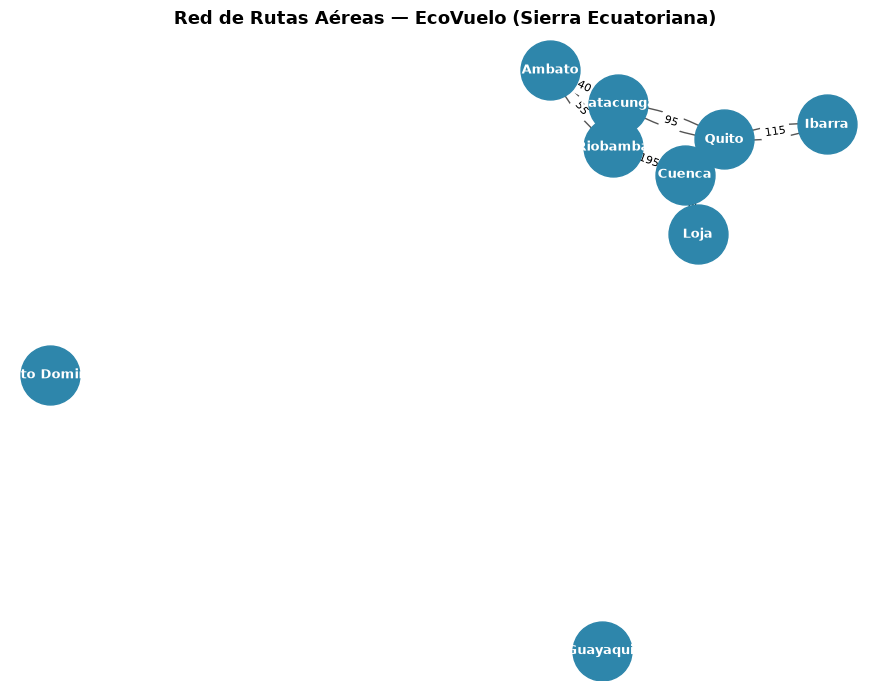



            SISTEMA DE RUTAS AÉREAS - ECOVUELO     

     1.  Añadir Ciudad                             
     2.  Eliminar Ciudad                           
     3.  Añadir Ruta                               
     4.  Eliminar Ruta                              
     5.  Buscar Ruta                               
     6.  Buscar Ciudad                             
     7.  Destinos Directos                         
     8.  Consultar Distancia                       
     9.  Calcular Conectividad (Grado)             
     10. BFS (Recorrido en Anchura)                
     11. DFS (Recorrido en Profundidad)            
     12. Mostrar todo el grafo                     
     13. Visualizar grafo                          
     0.  Salir                                     

    
Cerrando sistema EcoVuelo.


In [5]:
def menu(grafo: EcoVueloGraph):
    opc = '''
    
            SISTEMA DE RUTAS AÉREAS - ECOVUELO     
   
     1.  Añadir Ciudad                             
     2.  Eliminar Ciudad                           
     3.  Añadir Ruta                               
     4.  Eliminar Ruta                              
     5.  Buscar Ruta                               
     6.  Buscar Ciudad                             
     7.  Destinos Directos                         
     8.  Consultar Distancia                       
     9.  Calcular Conectividad (Grado)             
     10. BFS (Recorrido en Anchura)                
     11. DFS (Recorrido en Profundidad)            
     12. Mostrar todo el grafo                     
     13. Visualizar grafo                          
     0.  Salir                                     
   
    '''
    while True:
        print(opc)
        opcion = input("Seleccione una opción: ").strip()

        if opcion == "1":
            grafo.agregar_ciudad(input("Nombre de la nueva ciudad: ").strip())
        elif opcion == "2":
            grafo.eliminar_ciudad(input("Ciudad a eliminar: ").strip())
        elif opcion == "3":
            o = input("Ciudad origen: ").strip()
            d = input("Ciudad destino: ").strip()
            try:
                w = float(input("Distancia (km): ").strip())
                grafo.agregar_ruta(o, d, w)
            except ValueError:
                print("Distancia invalida.")
        elif opcion == "4":
            o = input("Ciudad origen: ").strip()
            d = input("Ciudad destino: ").strip()
            grafo.eliminar_ruta(o, d)
        elif opcion == "5":
            o = input("Ciudad origen: ").strip()
            d = input("Ciudad destino: ").strip()
            grafo.buscar_ruta(o, d)
        elif opcion == "6":
            grafo.buscar_ciudad(input("Ciudad a buscar: ").strip())
        elif opcion == "7":
            grafo.buscar_destinos_directos(input("Ciudad origen: ").strip())
        elif opcion == "8":
            o = input("Ciudad origen: ").strip()
            d = input("Ciudad destino: ").strip()
            grafo.consultar_distancia(o, d)
        elif opcion == "9":
            grafo.calcular_conectividad(input("Ciudad: ").strip())
        elif opcion == "10":
            grafo.bfs(input("Ciudad inicial: ").strip())
        elif opcion == "11":
            grafo.dfs(input("Ciudad inicial: ").strip())
        elif opcion == "12":
            grafo.mostrar_grafo()
        elif opcion == "13":
            draw_graph(grafo)
        elif opcion == "0":
            print("Cerrando sistema EcoVuelo.")
            break
        else:
            print("Opcion no valida, intente nuevamente.")


menu(red)
